<a href="https://colab.research.google.com/github/jiyanshud22/TEMP/blob/main/zoning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Zoning

# Zones:

W: WORKSTATIONS

E: ENCLOSED OFFICES

C: CAFE/PANTRY SUPPORT

L: COLLABORATIVE SEATING

M: MEETING SPACE/PHONE ROOM

S: SPECIALTY

R: RECEPTION/CLIENT-FACING COLLABORATIVE SPACE

# k ∈ {W, E, C, L, M, S, R}

#Decision Variables
 x ijk  be a binary variable :




  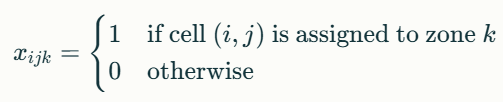

# Variables
Area Density: d

Capped task area:  **A task** = min
⁡
(
1278.46
,
d
×
∑
seats
)


Max seating capacity: **n seats**=⌊A task / d⌋


Side of Square

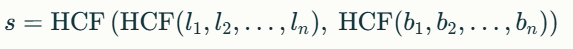

side length of square grid cells is HCF  to ensure all zones fit perfectly into the grid.

After that we get rows and column of grid:

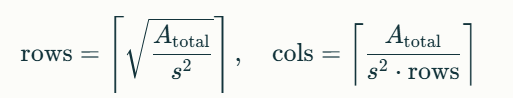

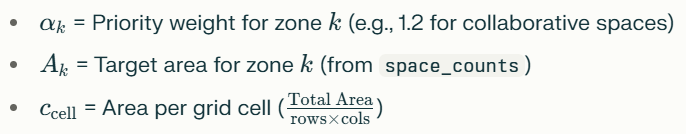


#Objective Function for Zoning


S ijk   is the suitability score of zone
k in cell
(i,j)

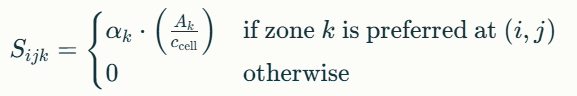

#Maximize total suitability

# 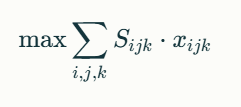

# Constarints

#Area Budget Constraint:
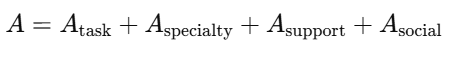

#(Adjacency Rules) collaborative zones near core

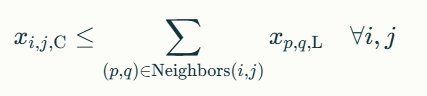

# Periphery Constraint (Workstations zones at edges)


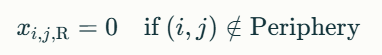

# Area for Zone k (e.g., workstations)


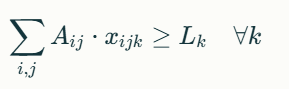

A k  is the target area for zone
k


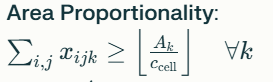

In [ ]:
import math
import random

# Sanofi H2O building data (default values)
sanofi_data = {
    "Ground Floor": {"area_sqm": 1595, "anchor_pct": 9.00, "collaborator_pct": 0.41, "density": 16.17},
    "Level 1": {"area_sqm": 1181, "anchor_pct": 5.85, "collaborator_pct": 0.30, "density": 30.37},
    "Level 2": {"area_sqm": 2363, "anchor_pct": 11.71, "collaborator_pct": 0.60, "density": 12.94},
    "Level 3": {"area_sqm": 2363, "anchor_pct": 11.71, "collaborator_pct": 0.60, "density": 12.94},
    "Level 4": {"area_sqm": 2363, "anchor_pct": 11.71, "collaborator_pct": 0.60, "density": 12.94},
    "Level 5": {"area_sqm": 2363, "anchor_pct": 11.71, "collaborator_pct": 0.60, "density": 12.94},
    "Level 6": {"area_sqm": 2363, "anchor_pct": 11.71, "collaborator_pct": 0.60, "density": 12.94},
    "Level 7": {"area_sqm": 2327, "anchor_pct": 11.53, "collaborator_pct": 0.59, "density": 23.59},
    "Level 8": {"area_sqm": 2281, "anchor_pct": 11.30, "collaborator_pct": 0.58, "density": 23.13}
}

# Default seat counts for Typical TF
typical_tf_seats = {
    "Individual Zone Work Desks (no partition)": 46,
    "Individual Zone Phone Booths (Single)": 3,
    "Individual Zone Phone Booths (Double)": 3,
    "Individual Zone Focus Rooms (1p)": 5,
    "Individual Zone Focus Rooms (2-3p)": 4,
    "Individual Zone Touchdown n Seats": 46,
    "Interactive Zone Work Desks (with partitions)": 36,
    "Interactive Zone Phone Booths (Single)": 3,
    "Interactive Zone Phone Booths (Double)": 3,
    "Interactive Zone Focus Rooms (1p)": 5,
    "Interactive Zone Focus Rooms (2-3p)": 4,
    "Interactive Zone Touchdown n Seats": 18
}

def calculate_hcf(a, b):
    while b:
        a, b = b, a % b
    return a

def calculate_grid_dimensions(total_area, zone_areas):
    # Approximate lengths based on zone proportions (e.g., 40% Workstations, 20% Collaboration, etc.)
    lengths = [int(total_area * 0.4), int(total_area * 0.2), int(total_area * 0.1), int(total_area * 0.1)]
    hcf = lengths[0]
    for i in range(1, len(lengths)):
        hcf = calculate_hcf(hcf, lengths[i])
    # Start with a square grid and adjust
    base = hcf
    rows = cols = int(math.sqrt(total_area / base))
    while rows * cols * base < total_area:
        if rows <= cols:
            rows += 1
        else:
            cols += 1
    return rows, cols

def calculate_area_from_seats(seat_counts, density):
    total_seats = sum(seat_counts.values())
    task_area = total_seats * density
    return task_area, total_seats

def calculate_default_areas(total_area, seat_counts, density):
    task_area, _ = calculate_area_from_seats(seat_counts, density)
    # Cap task_area if needed (e.g., 1278.46 for Typical TF)
    task_area = min(task_area, 1278.46)  # Adjust based on floor
    specialty = 250  # Default for Typical TF
    support = 195.30
    social = 91.32
    return {
        "Task": task_area,
        "Specialty": specialty,
        "Support": support,
        "Social": social,
        "Total": total_area
    }

def fill_zoning_grid(rows, cols, space_counts):
    total_cells = rows * cols
    if sum(space_counts.values()) != total_cells:
        print(f"Error: Sum of space categories must equal {total_cells}. Got {sum(space_counts.values())}.")
        return None

    grid = [[None] * cols for _ in range(rows)]

    # Define positions based on image layout (5x5 inspired)
    center_row = rows // 2
    center_col = cols // 2
    periphery = [(i, j) for i in range(rows) for j in range(cols) if i == 0 or i == rows-1 or j == 0 or j == cols-1]
    core = [(center_row, center_col)]
    entry = [(rows-1, center_col-1), (rows-1, center_col), (rows-1, center_col+1)]
    hub = [(i, j) for i in range(center_row-1, center_row+2) for j in range(center_col-1, center_col+2) if (i, j) not in core and (i, j) not in entry]
    quiet = [(i, j) for i in range(1, rows-1) for j in range(1, cols-1) if (i, j) not in hub and (i, j) not in core and (i, j) not in entry]

    # Fill regions
    for pos in entry:
        i, j = pos
        if space_counts.get('R', 0) > 0:
            grid[i][j] = 'R'
            space_counts['R'] -= 1

    for pos in core:
        i, j = pos
        if space_counts.get('C', 0) > 0:
            grid[i][j] = 'C'
            space_counts['C'] -= 1

    periphery_index = 0
    for pos in periphery:
        i, j = pos
        if grid[i][j] is None and space_counts.get('W', 0) > 0:
            grid[i][j] = 'W'
            space_counts['W'] -= 1
        periphery_index += 1

    for pos in hub:
        i, j = pos
        if grid[i][j] is None and space_counts.get('L', 0) > 0:
            grid[i][j] = 'L'
            space_counts['L'] -= 1

    for pos in quiet:
        i, j = pos
        if grid[i][j] is None and space_counts.get('M', 0) > 0:
            grid[i][j] = 'M'
            space_counts['M'] -= 1

    empty_positions = [(i, j) for i in range(rows) for j in range(cols) if grid[i][j] is None]
    random.shuffle(empty_positions)

    remaining_cats = []
    for cat, count in space_counts.items():
        remaining_cats.extend([cat] * count)
    random.shuffle(remaining_cats)

    for idx, (i, j) in enumerate(empty_positions):
        if idx < len(remaining_cats):
            grid[i][j] = remaining_cats[idx]

    return grid

# Main program
print("Available floors:", ", ".join(sanofi_data.keys()))
floor = input("Enter the floor to plan (e.g., Ground Floor, Level 2): ").strip()
if floor not in sanofi_data:
    print("Invalid floor. Using Level 2 as default.")
    floor = "Level 2"

floor_data = sanofi_data.get(floor, sanofi_data["Level 2"])
print(f"\nDefault Area Metrics for {floor}:")
print(f"Total Usable Area: {floor_data['area_sqm']} SQM")
print(f"Anchor Resident Area: {floor_data['area_sqm'] * (floor_data['anchor_pct'] / 100):.2f} SQM ({floor_data['anchor_pct']}%)")
print(f"Collaborator Area: {floor_data['area_sqm'] * (floor_data['collaborator_pct'] / 100):.2f} SQM ({floor_data['collaborator_pct']}%)")
print(f"Density: {floor_data['density']} SQM per seat")

# Override with user input
area_sqm = float(input(f"Enter Total Usable Area (SQM) [{floor_data['area_sqm']}]: ") or floor_data['area_sqm'])
anchor_pct = float(input(f"Enter Anchor Resident % [{floor_data['anchor_pct']}]: ") or floor_data['anchor_pct'])
collaborator_pct = float(input(f"Enter Collaborator % [{floor_data['collaborator_pct']}]: ") or floor_data['collaborator_pct'])
density = float(input(f"Enter Density (SQM per seat) [{floor_data['density']}]: ") or floor_data['density'])

print("\nEnter seat counts (default values for Typical TF in brackets):")
seat_counts = {}
for desc, default in typical_tf_seats.items():
    count = int(input(f"{desc} [{default}]: ") or default)
    seat_counts[desc] = count
task_area, total_seats = calculate_area_from_seats(seat_counts, density)
print(f"Calculated Task Area: {task_area:.2f} SQM (for {total_seats} seats)")

# Prompt for other areas
areas = {}
areas["Task"] = min(task_area, 1278.46)  # Cap for Typical TF
for cat, default in {"Specialty": 250, "Support": 195.30, "Social": 91.32}.items():
    value = float(input(f"Enter {cat} area (SQM) [{default}]: ") or default)
    areas[cat] = value
areas["Total"] = area_sqm

# Calculate grid dimensions
zone_areas = [areas["Task"], areas["Specialty"], areas["Support"], areas["Social"]]
rows, cols = calculate_grid_dimensions(area_sqm, zone_areas)
print(f"Calculated Grid Dimensions: {rows}x{cols}")

# Calculate cell counts
sqm_per_cell = area_sqm / (rows * cols)
space_counts = {
    "W": round(0.4 * areas["Task"] / sqm_per_cell),  # Workstations
    "E": round(0.1 * areas["Task"] / sqm_per_cell),  # Enclosed Offices (Focus)
    "C": round(0.2 * areas["Total"] / sqm_per_cell),  # Cafe/Pantry Support
    "L": round(0.2 * areas["Task"] / sqm_per_cell),  # Collaborative Seating
    "M": round(0.1 * areas["Task"] / sqm_per_cell),  # Meeting Space/Phone Room
    "S": round(areas["Specialty"] / sqm_per_cell),   # Specialty
    "R": round(0.1 * areas["Total"] / sqm_per_cell)  # Reception/Client-Facing
}
total_count = sum(space_counts.values())
if total_count != rows * cols:
    diff = rows * cols - total_count
    space_counts["W"] += diff  # Adjust Workstations

# Generate grid
grid = fill_zoning_grid(rows, cols, space_counts)

# Print results
print(f"\nZoning Plan for Sanofi H2O {floor} ({rows}x{cols} Grid):")
category_names = {
    "W": "WORKSTATIONS",
    "E": "ENCLOSED OFFICES",
    "C": "CAFE/PANTRY SUPPORT",
    "L": "COLLABORATIVE SEATING",
    "M": "MEETING SPACE/PHONE ROOM",
    "S": "SPECIALTY",
    "R": "RECEPTION/CLIENT-FACING COLLABORATIVE SPACE"
}
for row in grid:
    print(" ".join(f"{cell:<25}" for cell in row))

print("\nLegend:")
for code, name in category_names.items():
    print(f"{code}: {name}")
print(f"\nArea Summary:")
print(f"Task Area: {areas['Task']:.2f} SQM")
print(f"Specialty: {areas['Specialty']:.2f} SQM")
print(f"Support: {areas['Support']:.2f} SQM")
print(f"Social: {areas['Social']:.2f} SQM")
print(f"Total: {areas['Total']} SQM")
print(f"Density: {density} SQM per seat")

Available floors: Ground Floor, Level 1, Level 2, Level 3, Level 4, Level 5, Level 6, Level 7, Level 8
Enter the floor to plan (e.g., Ground Floor, Level 2): Level 2\
Invalid floor. Using Level 2 as default.

Default Area Metrics for Level 2:
Total Usable Area: 2363 SQM
Anchor Resident Area: 276.71 SQM (11.71%)
Collaborator Area: 14.18 SQM (0.6%)
Density: 12.94 SQM per seat
Enter Total Usable Area (SQM) [2363]: 2363
Enter Anchor Resident % [11.71]: 11.71
Enter Collaborator % [0.6]: .6
Enter Density (SQM per seat) [12.94]: 12.94

Enter seat counts (default values for Typical TF in brackets):
Individual Zone Work Desks (no partition) [46]: 46
Individual Zone Phone Booths (Single) [3]: 3
Individual Zone Phone Booths (Double) [3]: 3
Individual Zone Focus Rooms (1p) [5]: 5
Individual Zone Focus Rooms (2-3p) [4]: 4
Individual Zone Touchdown n Seats [46]: 46
Interactive Zone Work Desks (with partitions) [36]: 36
Interactive Zone Phone Booths (Single) [3]: 3
Interactive Zone Phone Booths (Doub

# here we see that we dont have the grid dimension, we have total area and percentage of area of zones. so we calculated the side length of square cell, which is HCF of all length and breath of rectangular zones to ensure all zones fit perfectly into the grid.

#we use big block constarint for zones to specify the sizes of the particular zones sites to be rectangular area less than percentage of area of that particular zones and all big blocks should add up to percentage of area of that particular zones

# After that we get rows and column of grid such that total area is covered by the square cells.


# then we apply constraints like W block(workstation) on pheriphery .C, L blocks(cafe and collaboration area)  in the core and zones dont spill out the limit of their percentage area allocated to them .
# Similarly , we can do the zoning for the other constraints

# If the Grid dimension are also specified (which is not the case for sanofi) then we can simply use our previous Multiple constraint methods

In [ ]:
import random

# Sanofi H2O building data (from Excel snippet)
sanofi_data = {
    "Ground Floor": {"area_sqm": 1595, "anchor_pct": 9.00, "collaborator_pct": 0.41, "density": 16.17, "seatcount": 1248, "headcount": 1980},
    "Level 1": {"area_sqm": 1181, "anchor_pct": 5.85, "collaborator_pct": 0.30, "density": 30.37, "seatcount": 64, "headcount": 220},
    "Level 2": {"area_sqm": 2363, "anchor_pct": 11.71, "collaborator_pct": 0.60, "density": 12.94, "seatcount": 1312, "headcount": 2200},
    "Level 3": {"area_sqm": 2363, "anchor_pct": 11.71, "collaborator_pct": 0.60, "density": 12.94, "seatcount": 1312, "headcount": 2200},
    "Level 4": {"area_sqm": 2363, "anchor_pct": 11.71, "collaborator_pct": 0.60, "density": 12.94, "seatcount": 1312, "headcount": 2200},
    "Level 5": {"area_sqm": 2363, "anchor_pct": 11.71, "collaborator_pct": 0.60, "density": 12.94, "seatcount": 1312, "headcount": 2200},
    "Level 6": {"area_sqm": 2363, "anchor_pct": 11.71, "collaborator_pct": 0.60, "density": 12.94, "seatcount": 1312, "headcount": 2200},
    "Level 7": {"area_sqm": 2327, "anchor_pct": 11.53, "collaborator_pct": 0.59, "density": 23.59, "seatcount": 64, "headcount": 220},
    "Level 8": {"area_sqm": 2281, "anchor_pct": 11.30, "collaborator_pct": 0.58, "density": 23.13, "seatcount": 64, "headcount": 220}
}

# Default seat counts for Typical TF (Levels 2–6)
typical_tf_seats = {
    "Individual Zone Work Desks (no partition)": 46,
    "Individual Zone Phone Booths (Single)": 3,
    "Individual Zone Phone Booths (Double)": 3,
    "Individual Zone Focus Rooms (1p)": 5,
    "Individual Zone Focus Rooms (2-3p)": 4,
    "Individual Zone Touchdown n Seats": 46,
    "Interactive Zone Work Desks (with partitions)": 36,
    "Interactive Zone Phone Booths (Single)": 3,
    "Interactive Zone Phone Booths (Double)": 3,
    "Interactive Zone Focus Rooms (1p)": 5,
    "Interactive Zone Focus Rooms (2-3p)": 4,
    "Interactive Zone Touchdown n Seats": 18
}

def calculate_area_from_seats(seat_counts, density):
    total_seats = sum(seat_counts.values())
    task_area = total_seats * density
    return task_area, total_seats

def calculate_default_areas(floor_data, seat_counts):
    area_sqm = floor_data["area_sqm"]
    density = floor_data["density"]
    task_area, total_seats = calculate_area_from_seats(seat_counts, density)
    # Cap task_area to 1278.46 SQM for Typical TF (Levels 2–6)
    typical_tf_floors = ["Level 2", "Level 3", "Level 4", "Level 5", "Level 6"]
    task_area = min(task_area, 1278.46) if floor in typical_tf_floors else task_area
    anchor_area = area_sqm * (floor_data["anchor_pct"] / 100)
    collaborator_area = area_sqm * (floor_data["collaborator_pct"] / 100)
    # Default areas from Excel (adjustable)
    specialty = 250 if area_sqm == 2363 else (1100 if area_sqm in [2327, 2281] else 450)
    support = 195.30 if area_sqm == 2363 else (191.46 if area_sqm == 2327 else 145.46)
    social = 91.32 if area_sqm == 2363 else 49.31
    return {
        "Task": task_area,
        "Specialty": specialty,
        "Support": support,
        "Social": social,
        "Total": area_sqm
    }

def calculate_cell_counts(areas, rows, cols):
    total_cells = rows * cols
    sqm_per_cell = areas["Total"] / total_cells
    counts = {
        "I": round(0.8 * areas["Task"] / sqm_per_cell),  # Individual Work
        "F": round(0.2 * areas["Task"] / sqm_per_cell),  # Focus
        "C": round((areas["Total"] - areas["Task"] - areas["Specialty"] - areas["Support"] - areas["Social"]) / sqm_per_cell),  # Collaboration
        "S": round(areas["Support"] / sqm_per_cell),
        "O": round(areas["Social"] / sqm_per_cell),
        "P": round(areas["Specialty"] / sqm_per_cell),
        "E": 1  # Minimal entry
    }
    # Adjust to match total_cells
    total_count = sum(counts.values())
    if total_count != total_cells:
        diff = total_cells - total_count
        counts["I"] += diff  # Adjust Workstations
    return counts

def fill_zoning_grid(rows, cols, space_counts, periphery_cats=None, core_cats=None, entry_cats=None):
    total_cells = rows * cols
    if sum(space_counts.values()) != total_cells:
        print(f"Error: Sum of space categories must equal {total_cells}. Got {sum(space_counts.values())}.")
        return None

    grid = [[None] * cols for _ in range(rows)]

    # Define positions
    periphery_positions = []
    for j in range(cols):
        periphery_positions.append((0, j))  # Top
    for i in range(1, rows):
        periphery_positions.append((i, cols - 1))  # Right
    for j in range(cols - 2, -1, -1):
        periphery_positions.append((rows - 1, j))  # Bottom
    for i in range(rows - 2, 0, -1):
        periphery_positions.append((i, 0))  # Left

    core_rows = max(1, rows // 3)
    core_cols = max(1, cols // 3)
    core_start_row = (rows - core_rows) // 2
    core_start_col = (cols - core_cols) // 2
    core_positions = [(i, j) for i in range(core_start_row, core_start_row + core_rows)
                      for j in range(core_start_col, core_start_col + core_cols)]

    entry_positions = [(0, 0), (0, 1), (1, 0), (1, 1)][:min(4, total_cells)]

    hub_positions = [(i, j) for i in range(1, rows - 1) for j in range(1, cols - 1)
                     if (i, j) not in core_positions]

    quiet_positions = [(i, j) for i in range(1, rows - 1) for j in range(1, cols - 1)
                       if (i, j) not in core_positions and (i, j) not in hub_positions]

    # Fill regions
    for pos in entry_positions:
        i, j = pos
        if entry_cats and space_counts.get('E', 0) > 0:
            grid[i][j] = 'E'
            space_counts['E'] -= 1

    for pos in core_positions:
        i, j = pos
        if grid[i][j] is None and core_cats and space_counts.get(core_cats[0], 0) > 0:
            grid[i][j] = core_cats[0]
            space_counts[core_cats[0]] -= 1

    periphery_index = 0
    periphery_cats = periphery_cats or []
    for pos in periphery_positions:
        i, j = pos
        if grid[i][j] is None:
            cat = periphery_cats[periphery_index % len(periphery_cats)] if periphery_cats else 'I'
            if space_counts.get(cat, 0) > 0:
                grid[i][j] = cat
                space_counts[cat] -= 1
            periphery_index += 1

    for pos in hub_positions:
        i, j = pos
        if grid[i][j] is None and space_counts.get('C', 0) > 0:
            grid[i][j] = 'C'
            space_counts['C'] -= 1

    for pos in quiet_positions:
        i, j = pos
        if grid[i][j] is None and space_counts.get('F', 0) > 0:
            grid[i][j] = 'F'
            space_counts['F'] -= 1

    empty_positions = [(i, j) for i in range(rows) for j in range(cols) if grid[i][j] is None]
    random.shuffle(empty_positions)

    remaining_cats = []
    for cat, count in space_counts.items():
        remaining_cats.extend([cat] * count)
    random.shuffle(remaining_cats)

    for idx, (i, j) in enumerate(empty_positions):
        if idx < len(remaining_cats):
            grid[i][j] = remaining_cats[idx]

    return grid

# Main program
print("Available floors:", ", ".join(sanofi_data.keys()))
floor = input("Enter the floor to plan (e.g., Ground Floor, Level 2): ").strip()
if floor not in sanofi_data:
    print("Invalid floor. Using Level 2 as default.")
    floor = "Level 2"

floor_data = sanofi_data[floor]
rows = int(input("Enter number of rows for the grid: "))
cols = int(input("Enter number of columns for the grid: "))
total_cells = rows * cols

# Display area metrics
area_sqm = floor_data["area_sqm"]
anchor_area = area_sqm * (floor_data["anchor_pct"] / 100)
collaborator_area = area_sqm * (floor_data["collaborator_pct"] / 100)
density = floor_data["density"]
print(f"\nArea Metrics for {floor}:")
print(f"Total Usable Area: {area_sqm} SQM")
print(f"Anchor Resident Area: {anchor_area:.2f} SQM ({floor_data['anchor_pct']}%)")
print(f"Collaborator Area: {collaborator_area:.2f} SQM ({floor_data['collaborator_pct']}%)")
print(f"Density: {density} SQM per seat")

# Prompt for seat counts
seat_counts = {}
print("\nEnter seat counts (default values for Typical TF in brackets):")
for desc, default in typical_tf_seats.items():
    code = desc.split()[0][0]  # Simplify to first letter for grid
    count = int(input(f"{desc} [{default}]: ") or default)
    seat_counts[desc] = count
task_area, total_seats = calculate_area_from_seats(seat_counts, density)
print(f"Calculated Task Area: {task_area:.2f} SQM (for {total_seats} seats)")

# Prompt for other areas (default from Excel)
default_areas = calculate_default_areas(floor_data, seat_counts)
areas = {}
for cat, default in {"Specialty": default_areas["Specialty"], "Support": default_areas["Support"], "Social": default_areas["Social"]}.items():
    value = float(input(f"Enter {cat} area (SQM) [{default}]: ") or default)
    areas[cat] = value
areas["Task"] = min(task_area, default_areas["Task"])  # Cap at Excel value
areas["Total"] = area_sqm

# Calculate cell counts
space_counts = calculate_cell_counts(areas, rows, cols)

# Define constraints
periphery_cats = ["I"]  # Individual Work on periphery
core_cats = ["S"]      # Support in core
entry_cats = ["E"]     # Entry zone

# Generate grid
grid = fill_zoning_grid(rows, cols, space_counts, periphery_cats, core_cats, entry_cats)

# Print results
print(f"\nZoning Plan for Sanofi H2O {floor} ({rows}x{cols} Grid):")
category_names = {
    "I": "Individual Work",
    "F": "Focus",
    "C": "Collaboration",
    "S": "Support",
    "O": "Social",
    "P": "Specialty",
    "E": "Entry"
}
for row in grid:
    print(" ".join(f"{cell:<2}" for cell in row))

print("\nLegend:")
for code, name in category_names.items():
    print(f"{code}: {name}")
print(f"\nArea Summary:")
print(f"Task Area: {areas['Task']:.2f} SQM")
print(f"Specialty: {areas['Specialty']:.2f} SQM")
print(f"Support: {areas['Support']:.2f} SQM")
print(f"Social: {areas['Social']:.2f} SQM")
print(f"Total: {areas['Total']} SQM")
print(f"Density: {density} SQM per seat")

Available floors: Ground Floor, Level 1, Level 2, Level 3, Level 4, Level 5, Level 6, Level 7, Level 8
Enter the floor to plan (e.g., Ground Floor, Level 2): Level 4
Enter number of rows for the grid: 10
Enter number of columns for the grid: 10

Area Metrics for Level 4:
Total Usable Area: 2363 SQM
Anchor Resident Area: 276.71 SQM (11.71%)
Collaborator Area: 14.18 SQM (0.6%)
Density: 12.94 SQM per seat

Enter seat counts (default values for Typical TF in brackets):
Individual Zone Work Desks (no partition) [46]: 46
Individual Zone Phone Booths (Single) [3]: 3
Individual Zone Phone Booths (Double) [3]: 3
Individual Zone Focus Rooms (1p) [5]: 5
Individual Zone Focus Rooms (2-3p) [4]: 4
Individual Zone Touchdown n Seats [46]: 46
Interactive Zone Work Desks (with partitions) [36]: 36
Interactive Zone Phone Booths (Single) [3]: 3
Interactive Zone Phone Booths (Double) [3]: 3
Interactive Zone Focus Rooms (1p) [5]: 5
Interactive Zone Focus Rooms (2-3p) [4]: 4
Interactive Zone Touchdown n Seat

In [ ]:
import random

# Sanofi H2O building data (from Excel, Scenario-1)
sanofi_data = {
    "Ground Floor": {
        "area_sqm": 1595,
        "categories": {
            "Task": 690.36,  # Individual + Interactive (Workstations, Focus, Touchdown)
            "Specialty": 450,
            "Support": 109.46,
            "Collaboration": 295.87,
            "Social": 49.31,
            "Entry": 0  # Assumed for client-facing/welcome
        }
    },
    "Level 1": {
        "area_sqm": 1181,
        "categories": {
            "Task": 272.21,
            "Specialty": 600,
            "Support": 172.68,
            "Collaboration": 116.66,
            "Social": 19.44,
            "Entry": 0
        }
    },
    "Level 2": {
        "area_sqm": 2363,
        "categories": {
            "Task": 1278.46,
            "Specialty": 250,
            "Support": 195.30,
            "Collaboration": 547.91,
            "Social": 91.32,
            "Entry": 0
        }
    },
    # Levels 3–6 same as Level 2
    "Level 3": {"area_sqm": 2363, "categories": {"Task": 1278.46, "Specialty": 250, "Support": 195.30, "Collaboration": 547.91, "Social": 91.32, "Entry": 0}},
    "Level 4": {"area_sqm": 2363, "categories": {"Task": 1278.46, "Specialty": 250, "Support": 195.30, "Collaboration": 547.91, "Social": 91.32, "Entry": 0}},
    "Level 5": {"area_sqm": 2363, "categories": {"Task": 1278.46, "Specialty": 250, "Support": 195.30, "Collaboration": 547.91, "Social": 91.32, "Entry": 0}},
    "Level 6": {"area_sqm": 2363, "categories": {"Task": 1278.46, "Specialty": 250, "Support": 195.30, "Collaboration": 547.91, "Social": 91.32, "Entry": 0}},
    "Level 7": {
        "area_sqm": 2327,
        "categories": {
            "Task": 690.36,
            "Specialty": 1100,
            "Support": 191.46,
            "Collaboration": 295.87,
            "Social": 49.31,
            "Entry": 0
        }
    },
    "Level 8": {
        "area_sqm": 2281,
        "categories": {
            "Task": 690.36,
            "Specialty": 1100,
            "Support": 145.46,
            "Collaboration": 295.87,
            "Social": 49.31,
            "Entry": 0
        }
    }
}

def calculate_default_counts(floor_data, rows, cols):
    total_cells = rows * cols
    area_sqm = floor_data["area_sqm"]
    sqm_per_cell = area_sqm / total_cells

    # Approximate Task as Workstations (80%) + Focus (20%)
    task_sqm = floor_data["categories"]["Task"]
    workstation_sqm = task_sqm * 0.8
    focus_sqm = task_sqm * 0.2

    # Convert SQM to cells
    counts = {
        "I": round(workstation_sqm / sqm_per_cell),  # Workstations
        "F": round(focus_sqm / sqm_per_cell),       # Focus Rooms/Phone Booths
        "C": round(floor_data["categories"]["Collaboration"] / sqm_per_cell),  # Collaboration
        "S": round(floor_data["categories"]["Support"] / sqm_per_cell),        # Support
        "O": round(floor_data["categories"]["Social"] / sqm_per_cell),         # Social
        "P": round(floor_data["categories"]["Specialty"] / sqm_per_cell),      # Specialty
        "E": round(floor_data["categories"]["Entry"] / sqm_per_cell)           # Entry
    }

    # Adjust counts to match total_cells
    total_count = sum(counts.values())
    if total_count != total_cells:
        # Scale proportionally
        factor = total_cells / total_count
        for key in counts:
            counts[key] = round(counts[key] * factor)
        # Fine-tune to exact total
        diff = total_cells - sum(counts.values())
        if diff > 0:
            counts["I"] += diff  # Add to workstations
        elif diff < 0:
            counts["I"] = max(0, counts["I"] + diff)  # Subtract from workstations

    return counts

def fill_zoning_grid(rows, cols, space_counts, periphery_cats=None, core_cats=None, entry_cats=None):
    total_cells = rows * cols
    if sum(space_counts.values()) != total_cells:
        print(f"Error: Sum of space categories must equal {total_cells}. Got {sum(space_counts.values())}.")
        return None

    # Initialize grid
    grid = [[None] * cols for _ in range(rows)]

    # Define positions
    # Periphery: Top, right, bottom, left edges
    periphery_positions = []
    for j in range(cols):
        periphery_positions.append((0, j))  # Top
    for i in range(1, rows):
        periphery_positions.append((i, cols - 1))  # Right
    for j in range(cols - 2, -1, -1):
        periphery_positions.append((rows - 1, j))  # Bottom
    for i in range(rows - 2, 0, -1):
        periphery_positions.append((i, 0))  # Left

    # Core: Center cells (approximate)
    core_rows = max(1, rows // 3)
    core_cols = max(1, cols // 3)
    core_start_row = (rows - core_rows) // 2
    core_start_col = (cols - core_cols) // 2
    core_positions = [(i, j) for i in range(core_start_row, core_start_row + core_rows)
                      for j in range(core_start_col, core_start_col + core_cols)]

    # Entry: Top-left corner
    entry_positions = [(0, 0), (0, 1), (1, 0), (1, 1)][:min(4, total_cells)]

    # Hub: Central but not core
    hub_positions = [(i, j) for i in range(1, rows - 1) for j in range(1, cols - 1)
                     if (i, j) not in core_positions]

    # Quiet zones: Non-periphery, non-entry, non-core
    quiet_positions = [(i, j) for i in range(1, rows - 1) for j in range(1, cols - 1)
                      if (i, j) not in core_positions and (i, j) not in hub_positions]

    # Fill entry positions
    for pos in entry_positions:
        i, j = pos
        if entry_cats and space_counts.get('E', 0) > 0:
            grid[i][j] = 'E'
            space_counts['E'] -= 1

    # Fill core positions (Support)
    for pos in core_positions:
        i, j = pos
        if grid[i][j] is not None:
            continue
        if core_cats and space_counts.get(core_cats[0], 0) > 0:
            grid[i][j] = core_cats[0]
            space_counts[core_cats[0]] -= 1

    # Fill periphery positions (Workstations)
    periphery_index = 0
    periphery_cats = periphery_cats or []
    for pos in periphery_positions:
        i, j = pos
        if grid[i][j] is not None:
            continue
        cat = periphery_cats[periphery_index % len(periphery_cats)] if periphery_cats else 'I'
        if space_counts.get(cat, 0) > 0:
            grid[i][j] = cat
            space_counts[cat] -= 1
        periphery_index += 1

    # Fill hub positions (Collaboration)
    for pos in hub_positions:
        i, j = pos
        if grid[i][j] is not None:
            continue
        if space_counts.get('C', 0) > 0:
            grid[i][j] = 'C'
            space_counts['C'] -= 1

    # Fill quiet zones (Focus)
    for pos in quiet_positions:
        i, j = pos
        if grid[i][j] is not None:
            continue
        if space_counts.get('F', 0) > 0:
            grid[i][j] = 'F'
            space_counts['F'] -= 1

    # Fill remaining with Social and Specialty
    empty_positions = [(i, j) for i in range(rows) for j in range(cols) if grid[i][j] is None]
    random.shuffle(empty_positions)

    remaining_cats = []
    for cat, count in space_counts.items():
        remaining_cats.extend([cat] * count)
    random.shuffle(remaining_cats)

    for idx, (i, j) in enumerate(empty_positions):
        if idx < len(remaining_cats):
            grid[i][j] = remaining_cats[idx]

    return grid

# Main program
print("Available floors:", ", ".join(sanofi_data.keys()))
floor = input("Enter the floor to plan (e.g., Ground Floor, Level 2): ").strip()
if floor not in sanofi_data:
    print("Invalid floor. Using Level 2 as default.")
    floor = "Level 2"

rows = int(input("Enter number of rows for the grid: "))
cols = int(input("Enter number of columns for the grid: "))
total_cells = rows * cols

# Get default counts from Sanofi data
default_counts = calculate_default_counts(sanofi_data[floor], rows, cols)

# Display defaults and ask for overrides
print("\nDefault space category counts (based on Sanofi data):")
category_names = {
    "I": "Workstation",
    "F": "Focus",
    "C": "Collaboration",
    "S": "Support",
    "O": "Social",
    "P": "Specialty",
    "E": "Entry"
}
for code, name in category_names.items():
    print(f"{name} ({code}): {default_counts.get(code, 0)} cells")

use_defaults = input("\nUse default counts? (y/n): ").strip().lower() == 'y'

if use_defaults:
    space_counts = default_counts
else:
    print("\nEnter custom cell counts for each category (must sum to", total_cells, "):")
    space_counts = {}
    for code, name in category_names.items():
        count = int(input(f"Number of {name} ({code}) cells: "))
        space_counts[code] = count

    # Validate total
    if sum(space_counts.values()) != total_cells:
        print("Error: Total cell counts do not match grid size. Adjusting Workstations.")
        space_counts["I"] += total_cells - sum(space_counts.values())

# Define constraints
periphery_cats = ["I"]  # Workstations on periphery
core_cats = ["S"]      # Support in core
entry_cats = ["E"]     # Entry zone

# Generate grid
grid = fill_zoning_grid(rows, cols, space_counts, periphery_cats, core_cats, entry_cats)

# Print grid
print(f"\nZoning Plan for Sanofi H2O {floor} ({rows}x{cols} Grid):")
for row in grid:
    print(" ".join(f"{cell:<2}" for cell in row))

# Print legend
print("\nLegend:")
for code, name in category_names.items():
    print(f"{code}: {name}")

Available floors: Ground Floor, Level 1, Level 2, Level 3, Level 4, Level 5, Level 6, Level 7, Level 8
Enter the floor to plan (e.g., Ground Floor, Level 2): Level 2
Enter number of rows for the grid: 5
Enter number of columns for the grid: 5

Default space category counts (based on Sanofi data):
Workstation (I): 10 cells
Focus (F): 3 cells
Collaboration (C): 6 cells
Support (S): 2 cells
Social (O): 1 cells
Specialty (P): 3 cells
Entry (E): 0 cells

Use default counts? (y/n): n

Enter custom cell counts for each category (must sum to 25 ):
Number of Workstation (I) cells: 5
Number of Focus (F) cells: 8
Number of Collaboration (C) cells: 3
Number of Support (S) cells: 4
Number of Social (O) cells: 1
Number of Specialty (P) cells: 2
Number of Entry (E) cells: 2

Zoning Plan for Sanofi H2O Level 2 (5x5 Grid):
E  E  I  I  I 
F  C  C  C  I 
F  S  S  P  I 
P  F  S  F  F 
O  S  F  F  F 

Legend:
I: Workstation
F: Focus
C: Collaboration
S: Support
O: Social
P: Specialty
E: Entry
